<a href="https://colab.research.google.com/github/Wuanzz/FER-Video-Emotion-Recognition/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELL 1 - Cài thư viện

In [14]:
# ============================================================
# CELL 1 — INSTALL LIBRARIES
# ============================================================

# Gỡ các phiên bản OpenCV có thể gây xung đột
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless -q

# Cài OpenCV 4.x để tương thích với Haar Cascade
!pip install -q opencv-python-headless==4.10.0.84

# Cài Gradio
!pip install -q gradio

print("========================================")
print("Installation completed.")
print("OpenCV: 4.10.0.84")
print("Gradio: installed")
print("========================================")

Installation completed.
OpenCV: 4.10.0.84
Gradio: installed


CELL 2 - Mount Google Drive

In [1]:
# ============================================================
# CELL 2 — GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


CELL 3 - Import thư viện + kiểm tra OpenCV

In [2]:
# ============================================================
# CELL 3 — IMPORT LIBRARIES + CHECK OPENCV
# ============================================================

import os
import cv2
import numpy as np
import torch
import torch.nn as nn

from torchvision import models, transforms

print("========================================")
print("ENVIRONMENT CHECK")
print("========================================")

print("OpenCV version:")
print(cv2.__version__)

print("\nOpenCV location:")
print(cv2.__file__)

print("\nCascadeClassifier available:")
print(hasattr(cv2, "CascadeClassifier"))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nPyTorch device:")
print(device)

print("========================================")

ENVIRONMENT CHECK
OpenCV version:
4.10.0

OpenCV location:
/usr/local/lib/python3.13/dist-packages/cv2/__init__.py

CascadeClassifier available:
True

PyTorch device:
cuda


CELL 4 - Cấu hình dự án

In [3]:
# ============================================================
# CELL 4 — PROJECT CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Đường dẫn project trong Google Drive
# ------------------------------------------------------------

PROJECT_DIR = (
    "/content/drive/MyDrive/"
    "Công nghệ phần mềm nâng cao/"
    "Project_FER_Video"
)

# ------------------------------------------------------------
# Đường dẫn model
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "checkpoints",
    "best_model.pth"
)

# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

CLASS_NAMES = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised"
]

IMAGE_SIZE = (
    224,
    224
)

SEQUENCE_LENGTH = 16

# ------------------------------------------------------------
# Kiểm tra
# ------------------------------------------------------------

print("========================================")
print("PROJECT CONFIGURATION")
print("========================================")

print("Project directory:")
print(PROJECT_DIR)

print("\nModel path:")
print(MODEL_PATH)

print("\nModel exists:")
print(os.path.exists(MODEL_PATH))

print("\nClasses:")

for i, emotion in enumerate(CLASS_NAMES):
    print(
        f"{i}: {emotion}"
    )

print("\nImage size:")
print(IMAGE_SIZE)

print("\nSequence length:")
print(SEQUENCE_LENGTH)

print("========================================")

PROJECT CONFIGURATION
Project directory:
/content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video

Model path:
/content/drive/MyDrive/Công nghệ phần mềm nâng cao/Project_FER_Video/checkpoints/best_model.pth

Model exists:
True

Classes:
0: neutral
1: calm
2: happy
3: sad
4: angry
5: fearful
6: disgust
7: surprised

Image size:
(224, 224)

Sequence length:
16


CELL 5 - Haar Cascade Face Detector

In [4]:
# ============================================================
# CELL 5 — HAAR CASCADE FACE DETECTOR
# ============================================================

import cv2
import os

cascade_path = (
    cv2.data.haarcascades
    + "haarcascade_frontalface_default.xml"
)

print("Cascade path:")
print(cascade_path)

print("\nCascade file exists:")
print(
    os.path.exists(cascade_path)
)

# ------------------------------------------------------------
# Create detector
# ------------------------------------------------------------

face_cascade = cv2.CascadeClassifier(
    cascade_path
)

# ------------------------------------------------------------
# Validate detector
# ------------------------------------------------------------

if face_cascade.empty():

    raise RuntimeError(
        "Không thể load Haar Cascade!"
    )

print("\n========================================")
print("✓ Haar Cascade Face Detector: OK")
print("========================================")

Cascade path:
/usr/local/lib/python3.13/dist-packages/cv2/data/haarcascade_frontalface_default.xml

Cascade file exists:
True

✓ Haar Cascade Face Detector: OK


CELL 6 - Video Preprocessing

In [5]:
# ============================================================
# CELL 6 — VIDEO PREPROCESSING
# ============================================================

def process_video(
    video_path,
    sequence_length=16,
    image_size=(224, 224)
):
    """
    Preprocess video theo pipeline của nhóm:

    Video
        ↓
    Frame Sampling
        ↓
    Haar Cascade Face Detection
        ↓
    Largest Face
        ↓
    10% Padding
        ↓
    Crop
        ↓
    RGB
        ↓
    Resize 224 x 224

    Output:
        numpy array

    Shape:
        (16, 224, 224, 3)

    Dtype:
        uint8
    """

    # ========================================================
    # 1. OPEN VIDEO
    # ========================================================

    cap = cv2.VideoCapture(
        video_path
    )

    if not cap.isOpened():

        raise ValueError(
            f"Không thể mở video: {video_path}"
        )

    # ========================================================
    # 2. GET TOTAL FRAMES
    # ========================================================

    total_frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )

    if total_frames <= 0:

        cap.release()

        raise ValueError(
            "Video không có frame hợp lệ."
        )

    # ========================================================
    # 3. SAMPLE 16 FRAMES
    # ========================================================

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        sequence_length,
        dtype=int
    )

    frames = []

    # ========================================================
    # 4. PROCESS EACH FRAME
    # ========================================================

    for frame_idx in frame_indices:

        # ----------------------------------------------------
        # Seek frame
        # ----------------------------------------------------

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(frame_idx)
        )

        success, frame = cap.read()

        # ----------------------------------------------------
        # Handle failed frame
        # ----------------------------------------------------

        if (
            not success
            or frame is None
        ):

            if len(frames) > 0:

                frames.append(
                    frames[-1].copy()
                )

            continue

        # ----------------------------------------------------
        # Convert BGR -> Grayscale
        # ----------------------------------------------------

        gray = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2GRAY
        )

        # ----------------------------------------------------
        # Face Detection
        # ----------------------------------------------------

        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )

        # ----------------------------------------------------
        # Crop largest face
        # ----------------------------------------------------

        if len(faces) > 0:

            # Chọn khuôn mặt lớn nhất
            x, y, w, h = max(
                faces,
                key=lambda rect:
                    rect[2] * rect[3]
            )

            # ------------------------------------------------
            # 10% padding
            # ------------------------------------------------

            pad_x = int(
                0.1 * w
            )

            pad_y = int(
                0.1 * h
            )

            x1 = max(
                0,
                x - pad_x
            )

            y1 = max(
                0,
                y - pad_y
            )

            x2 = min(
                frame.shape[1],
                x + w + pad_x
            )

            y2 = min(
                frame.shape[0],
                y + h + pad_y
            )

            face = frame[
                y1:y2,
                x1:x2
            ]

        else:

            # ------------------------------------------------
            # Nếu không detect được face
            # dùng toàn bộ frame
            # ------------------------------------------------

            face = frame

        # ----------------------------------------------------
        # BGR -> RGB
        # ----------------------------------------------------

        face = cv2.cvtColor(
            face,
            cv2.COLOR_BGR2RGB
        )

        # ----------------------------------------------------
        # Resize 224 x 224
        # ----------------------------------------------------

        face = cv2.resize(
            face,
            image_size
        )

        frames.append(
            face
        )

    # ========================================================
    # 5. RELEASE VIDEO
    # ========================================================

    cap.release()

    # ========================================================
    # 6. CHECK RESULT
    # ========================================================

    if len(frames) == 0:

        raise ValueError(
            "Không thể trích xuất frame từ video."
        )

    # ========================================================
    # 7. PAD IF NECESSARY
    # ========================================================

    while len(frames) < sequence_length:

        frames.append(
            frames[-1].copy()
        )

    # ========================================================
    # 8. EXACTLY 16 FRAMES
    # ========================================================

    frames = frames[
        :sequence_length
    ]

    # ========================================================
    # 9. RETURN
    # ========================================================

    return np.array(
        frames,
        dtype=np.uint8
    )


print("✓ Video preprocessing function ready.")

✓ Video preprocessing function ready.


CELL 7 - Upload video để test preprocessing

In [6]:
# ============================================================
# CELL 7 — TEST VIDEO PREPROCESSING
# ============================================================

from google.colab import files

print("Hãy upload một video ngắn có khuôn mặt.")

uploaded = files.upload()

if len(uploaded) == 0:

    raise ValueError(
        "Bạn chưa upload video."
    )

TEST_VIDEO_PATH = next(
    iter(uploaded.keys())
)

print("\nVideo selected:")
print(TEST_VIDEO_PATH)

# ------------------------------------------------------------
# Process video
# ------------------------------------------------------------

test_sequence = process_video(
    TEST_VIDEO_PATH,
    sequence_length=SEQUENCE_LENGTH,
    image_size=IMAGE_SIZE
)

# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

print("\n========================================")
print("PREPROCESSING RESULT")
print("========================================")

print(
    "Shape:",
    test_sequence.shape
)

print(
    "Dtype:",
    test_sequence.dtype
)

print(
    "Min value:",
    test_sequence.min()
)

print(
    "Max value:",
    test_sequence.max()
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert test_sequence.shape == (
    16,
    224,
    224,
    3
)

print("\n✓ PREPROCESSING PASSED")

Hãy upload một video ngắn có khuôn mặt.


Saving WIN_20250613_08_58_46_Pro.jpg to WIN_20250613_08_58_46_Pro.jpg

Video selected:
WIN_20250613_08_58_46_Pro.jpg

PREPROCESSING RESULT
Shape: (16, 224, 224, 3)
Dtype: uint8
Min value: 0
Max value: 255

✓ PREPROCESSING PASSED


CELL 8 - Model Architecture

In [7]:
# ============================================================
# CELL 8 — SPATIAL-TEMPORAL FER MODEL
# ============================================================

class SpatialTemporalFERModel(
    nn.Module
):

    def __init__(
        self,
        backbone_name="resnet18",
        rnn_type="LSTM",
        hidden_dim=256,
        num_rnn_layers=2,
        dropout=0.5,
        num_classes=8
    ):

        super().__init__()

        # ====================================================
        # CNN BACKBONE
        # ====================================================

        if backbone_name == "resnet18":

            resnet = models.resnet18(
                weights=None
            )

            feature_dim = (
                resnet.fc.in_features
            )

            # Remove final FC
            resnet.fc = nn.Identity()

            self.backbone = resnet

        elif backbone_name == "mobilenet_v2":

            mobilenet = models.mobilenet_v2(
                weights=None
            )

            feature_dim = (
                mobilenet.classifier[1]
                .in_features
            )

            mobilenet.classifier = (
                nn.Identity()
            )

            self.backbone = mobilenet

        else:

            raise ValueError(
                f"Unsupported backbone: "
                f"{backbone_name}"
            )

        # ====================================================
        # RNN
        # ====================================================

        self.rnn_type = rnn_type

        if rnn_type == "LSTM":

            self.rnn = nn.LSTM(
                input_size=feature_dim,
                hidden_size=hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=True,
                dropout=(
                    dropout
                    if num_rnn_layers > 1
                    else 0
                )
            )

        elif rnn_type == "GRU":

            self.rnn = nn.GRU(
                input_size=feature_dim,
                hidden_size=hidden_dim,
                num_layers=num_rnn_layers,
                batch_first=True,
                bidirectional=True,
                dropout=(
                    dropout
                    if num_rnn_layers > 1
                    else 0
                )
            )

        else:

            raise ValueError(
                f"Unsupported RNN: {rnn_type}"
            )

        # ====================================================
        # CLASSIFIER
        # ====================================================

        rnn_output_dim = (
            hidden_dim * 2
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                rnn_output_dim,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        # ====================================================
        # INPUT
        # ====================================================
        #
        # Expected:
        # (B, T, C, H, W)
        #
        # Also support:
        # (B, T, H, W, C)
        # ====================================================

        if (
            x.dim() == 5
            and x.shape[-1] == 3
        ):

            x = x.permute(
                0,
                1,
                4,
                2,
                3
            )

        batch_size = x.shape[0]
        sequence_length = x.shape[1]

        C = x.shape[2]
        H = x.shape[3]
        W = x.shape[4]

        # ====================================================
        # CNN
        # ====================================================

        x = x.reshape(
            batch_size * sequence_length,
            C,
            H,
            W
        )

        cnn_features = self.backbone(
            x
        )

        # ====================================================
        # RESHAPE FOR RNN
        # ====================================================

        rnn_input = cnn_features.reshape(
            batch_size,
            sequence_length,
            -1
        )

        # ====================================================
        # BIDIRECTIONAL LSTM
        # ====================================================

        rnn_output, _ = self.rnn(
            rnn_input
        )

        # ====================================================
        # TEMPORAL MEAN
        # ====================================================

        temporal_feature = torch.mean(
            rnn_output,
            dim=1
        )

        # ====================================================
        # CLASSIFIER
        # ====================================================

        logits = self.classifier(
            temporal_feature
        )

        return logits


print("✓ Model architecture defined.")

✓ Model architecture defined.


CELL 9 - Load checkpoint

In [8]:
# ============================================================
# CELL 9 — LOAD CHECKPOINT
# ============================================================

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        f"Không tìm thấy model:\n"
        f"{MODEL_PATH}"
    )

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

print("========================================")
print("CHECKPOINT INFORMATION")
print("========================================")

print(
    "Checkpoint keys:"
)

for key in checkpoint.keys():

    print(
        "-",
        key
    )

print("\nModel configuration:")

MODEL_CONFIG = checkpoint[
    "config"
]

for key, value in MODEL_CONFIG.items():

    print(
        f"{key}: {value}"
    )

print("\nBest epoch:")

print(
    checkpoint.get(
        "epoch",
        "N/A"
    )
)

print("\nValidation accuracy:")

val_acc = checkpoint.get(
    "val_acc",
    None
)

if val_acc is not None:

    print(
        f"{val_acc * 100:.2f}%"
    )

else:

    print("N/A")

print("========================================")

CHECKPOINT INFORMATION
Checkpoint keys:
- epoch
- model_state_dict
- optimizer_state_dict
- val_acc
- config

Model configuration:
image_size: (224, 224)
sequence_length: 16
num_classes: 8
backbone: resnet18
rnn_type: LSTM
hidden_dim: 256
num_rnn_layers: 2
dropout: 0.5
batch_size: 16
learning_rate: 0.0001
weight_decay: 0.0001
num_epochs: 30
seed: 42

Best epoch:
13

Validation accuracy:
81.58%


CELL 10 - Khởi tạo model và load weights

In [9]:
# ============================================================
# CELL 10 — INITIALIZE + LOAD MODEL
# ============================================================

model = SpatialTemporalFERModel(

    backbone_name=MODEL_CONFIG[
        "backbone"
    ],

    rnn_type=MODEL_CONFIG[
        "rnn_type"
    ],

    hidden_dim=MODEL_CONFIG[
        "hidden_dim"
    ],

    num_rnn_layers=MODEL_CONFIG[
        "num_rnn_layers"
    ],

    dropout=MODEL_CONFIG[
        "dropout"
    ],

    num_classes=MODEL_CONFIG[
        "num_classes"
    ]
)

# ------------------------------------------------------------
# Load trained weights
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

# ------------------------------------------------------------
# Move model to device
# ------------------------------------------------------------

model = model.to(
    device
)

# ------------------------------------------------------------
# Evaluation mode
# ------------------------------------------------------------

model.eval()

print("========================================")
print("MODEL LOADED SUCCESSFULLY")
print("========================================")

print(
    "Backbone:",
    MODEL_CONFIG["backbone"]
)

print(
    "RNN:",
    MODEL_CONFIG["rnn_type"]
)

print(
    "Hidden dimension:",
    MODEL_CONFIG["hidden_dim"]
)

print(
    "RNN layers:",
    MODEL_CONFIG["num_rnn_layers"]
)

print(
    "Device:",
    device
)

print("========================================")

MODEL LOADED SUCCESSFULLY
Backbone: resnet18
RNN: LSTM
Hidden dimension: 256
RNN layers: 2
Device: cuda


CELL 11 - Model Transform

In [10]:
# ============================================================
# CELL 11 — MODEL TRANSFORM
# ============================================================

model_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

print("✓ Image transformation ready.")

✓ Image transformation ready.


CELL 12 - Convert 16 frames → Tensor

In [11]:
# ============================================================
# CELL 12 — PREPARE MODEL INPUT
# ============================================================

def prepare_model_input(
    frames
):
    """
    Input:

        (16, 224, 224, 3)

    Output:

        (1, 16, 3, 224, 224)
    """

    processed_frames = []

    # --------------------------------------------------------
    # Transform each frame
    # --------------------------------------------------------

    for frame in frames:

        frame_tensor = model_transform(
            frame
        )

        processed_frames.append(
            frame_tensor
        )

    # --------------------------------------------------------
    # Stack frames
    # --------------------------------------------------------

    video_tensor = torch.stack(
        processed_frames,
        dim=0
    )

    # --------------------------------------------------------
    # Add batch dimension
    # --------------------------------------------------------

    video_tensor = video_tensor.unsqueeze(
        0
    )

    return video_tensor


print("✓ Model input preparation function ready.")

✓ Model input preparation function ready.


CELL 13 - Prediction Function

In [12]:
# ============================================================
# CELL 13 — EMOTION PREDICTION
# ============================================================

def predict_emotion(
    video_path
):

    # ========================================================
    # 1. VIDEO PREPROCESSING
    # ========================================================

    frames = process_video(

        video_path,

        sequence_length=(
            SEQUENCE_LENGTH
        ),

        image_size=(
            IMAGE_SIZE
        )
    )

    # ========================================================
    # 2. PREPARE MODEL INPUT
    # ========================================================

    video_tensor = prepare_model_input(
        frames
    )

    video_tensor = video_tensor.to(
        device
    )

    # ========================================================
    # 3. MODEL INFERENCE
    # ========================================================

    with torch.no_grad():

        logits = model(
            video_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    # ========================================================
    # 4. PREDICTED CLASS
    # ========================================================

    predicted_index = torch.argmax(
        probabilities
    ).item()

    predicted_emotion = (
        CLASS_NAMES[
            predicted_index
        ]
    )

    # ========================================================
    # 5. CONFIDENCE
    # ========================================================

    confidence = probabilities[
        predicted_index
    ].item()

    # ========================================================
    # 6. ALL PROBABILITIES
    # ========================================================

    probability_dict = {

        CLASS_NAMES[i]:
            float(
                probabilities[i].item()
            )

        for i in range(
            len(CLASS_NAMES)
        )
    }

    return (
        predicted_emotion,
        confidence,
        probability_dict
    )


print("✓ Prediction function ready.")

✓ Prediction function ready.


CELL 14 - Test model prediction

In [13]:
# ============================================================
# CELL 14 — TEST MODEL
# ============================================================

emotion, confidence, probabilities = (
    predict_emotion(
        TEST_VIDEO_PATH
    )
)

print("========================================")
print("PREDICTION RESULT")
print("========================================")

print(
    "Predicted emotion:"
)

print(
    emotion.upper()
)

print(
    "\nConfidence:"
)

print(
    f"{confidence * 100:.2f}%"
)

print(
    "\nEmotion probabilities:"
)

for emotion_name, probability in (
    probabilities.items()
):

    print(
        f"{emotion_name:10s} : "
        f"{probability * 100:.2f}%"
    )

print("========================================")

PREDICTION RESULT
Predicted emotion:
DISGUST

Confidence:
46.39%

Emotion probabilities:
neutral    : 0.76%
calm       : 9.69%
happy      : 0.09%
sad        : 38.55%
angry      : 0.56%
fearful    : 3.57%
disgust    : 46.39%
surprised  : 0.39%


CELL 15 - Probability Chart

In [14]:
# ============================================================
# CELL 15 — PROBABILITY VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt


def create_probability_chart(
    probability_dict
):

    emotions = list(
        probability_dict.keys()
    )

    probability_values = [
        probability_dict[
            emotion
        ]

        for emotion in emotions
    ]

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    # --------------------------------------------------------
    # Bar chart
    # --------------------------------------------------------

    ax.bar(
        emotions,
        probability_values
    )

    # --------------------------------------------------------
    # Axis
    # --------------------------------------------------------

    ax.set_ylim(
        0,
        1
    )

    ax.set_xlabel(
        "Emotion"
    )

    ax.set_ylabel(
        "Probability"
    )

    ax.set_title(
        "Emotion Probability Distribution"
    )

    # --------------------------------------------------------
    # Rotate labels
    # --------------------------------------------------------

    ax.tick_params(
        axis="x",
        rotation=30
    )

    # --------------------------------------------------------
    # Percentage labels
    # --------------------------------------------------------

    for i, value in enumerate(
        probability_values
    ):

        ax.text(

            i,

            min(
                value + 0.02,
                0.98
            ),

            f"{value * 100:.1f}%",

            ha="center"
        )

    plt.tight_layout()

    return fig


print(
    "✓ Probability chart function ready."
)

✓ Probability chart function ready.


CELL 16 - Test biểu đồ

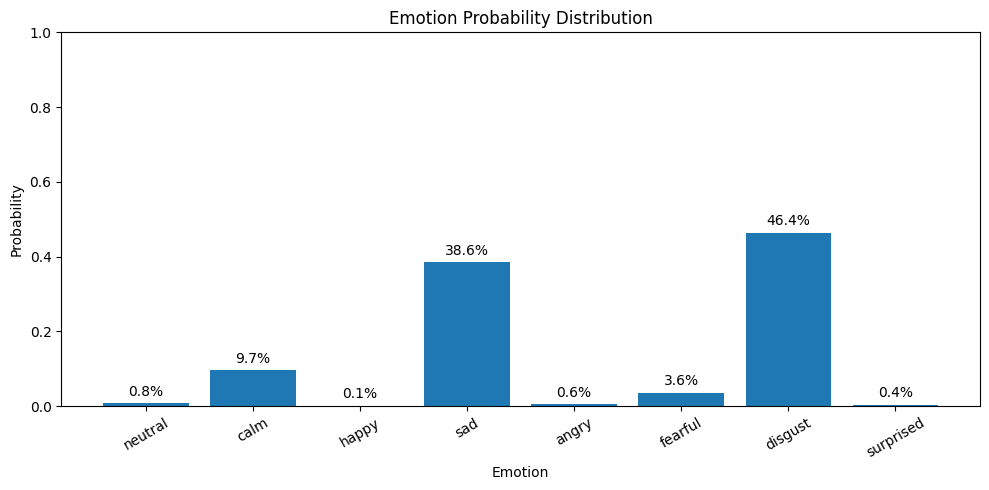

In [15]:
# ============================================================
# CELL 16 — TEST PROBABILITY CHART
# ============================================================

fig = create_probability_chart(
    probabilities
)

plt.show()

CELL 17 - Hàm dành cho Gradio

In [16]:
# ============================================================
# CELL 17 — GRADIO PREDICTION FUNCTION
# ============================================================

def gradio_predict(
    video_path
):

    # --------------------------------------------------------
    # No video
    # --------------------------------------------------------

    if video_path is None:

        return (
            "Chưa upload video",
            0.0,
            None
        )

    try:

        # ----------------------------------------------------
        # Predict
        # ----------------------------------------------------

        emotion, confidence, probabilities = (
            predict_emotion(
                video_path
            )
        )

        # ----------------------------------------------------
        # Create chart
        # ----------------------------------------------------

        chart = create_probability_chart(
            probabilities
        )

        # ----------------------------------------------------
        # Return to Gradio
        # ----------------------------------------------------

        return (

            emotion.upper(),

            confidence * 100,

            chart
        )

    except Exception as e:

        print(
            "Prediction error:",
            str(e)
        )

        return (

            f"ERROR: {str(e)}",

            0.0,

            None
        )


print("✓ Gradio prediction function ready.")

✓ Gradio prediction function ready.


CELL 18 - Tạo giao diện Gradio

In [18]:
# ============================================================
# CELL 18 — CREATE GRADIO WEB DEMO
# ============================================================

import gradio as gr


with gr.Blocks(
    title="Facial Emotion Recognition"
) as demo:

    # ========================================================
    # HEADER
    # ========================================================

    gr.Markdown(
        """
        # 🎭 Facial Emotion Recognition

        ### Video-based Human Emotion Recognition

        Upload a short video and let the model
        predict the facial emotion.
        """
    )

    # ========================================================
    # INPUT + OUTPUT
    # ========================================================

    with gr.Row():

        # ----------------------------------------------------
        # LEFT COLUMN
        # ----------------------------------------------------

        with gr.Column():

            video_input = gr.Video(
                label="Upload Video"
            )

            predict_button = gr.Button(
                "🔍 Predict Emotion",
                variant="primary"
            )

        # ----------------------------------------------------
        # RIGHT COLUMN
        # ----------------------------------------------------

        with gr.Column():

            emotion_output = gr.Textbox(
                label="Predicted Emotion"
            )

            confidence_output = gr.Number(
                label="Confidence (%)",
                precision=2
            )

    # ========================================================
    # PROBABILITY CHART
    # ========================================================

    probability_output = gr.Plot(
        label="Emotion Probability Distribution"
    )

    # ========================================================
    # INFORMATION
    # ========================================================

    gr.Markdown(
        """
        ### Supported Emotions

        Neutral · Calm · Happy · Sad ·
        Angry · Fearful · Disgust · Surprised

        ### Model

        ResNet18 + Bidirectional LSTM
        """
    )

    # ========================================================
    # BUTTON EVENT
    # ========================================================

    predict_button.click(
        fn=gradio_predict,
        inputs=video_input,
        outputs=[
            emotion_output,
            confidence_output,
            probability_output
        ]
    )


print(
    "✓ Gradio interface created successfully."
)

✓ Gradio interface created successfully.


CELL 19 - Chạy Web Demo

In [19]:
# ============================================================
# CELL 19 — LAUNCH GRADIO WEB DEMO
# ============================================================

print("Starting Gradio Web Demo...")

demo.launch(
    share=True,
    debug=True
)

Starting Gradio Web Demo...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8bed170a3b46ef7a8e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.scope, self.receive, self.send
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/applications.py", line 96, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/middleware/errors.py", line 186, i

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8bed170a3b46ef7a8e.gradio.live


# Mục mới